### Bootstrapping ###

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [4]:
url = (
    "https://raw.githubusercontent.com/ranalytics/"
    "r-tutorials/master/Edition_2015/Data/RIKZ.txt"
)

rikz = pd.read_csv(url, sep="\t")

print(rikz.shape)
print(rikz.columns)
print(rikz.head())
print(len(rikz))

(45, 5)
Index(['Sample', 'Richness', 'Exposure', 'NAP', 'Beach'], dtype='object')
   Sample  Richness  Exposure    NAP  Beach
0       1        11        10  0.045      1
1       2        10        10 -1.036      1
2       3        13        10 -1.336      1
3       4        11        10  0.616      1
4       5        10        10 -0.684      1
45


The data, which can be accessed via the Data4Ecologists library, were collected at 5 stations at each of 9 beaches. The beaches were located at 3 different levels of exposure to waves (high, medium, or low). For now, we will focus on the following variables:

- Richness = species richness (i.e., the number of species counted).
- NAP = height of the sample site (relative to sea level). Lower values indicate sites closer to or further below sea level, which implies more time spent submerged.
- Beach = a unique identifier for the specific beach where the observation occurred

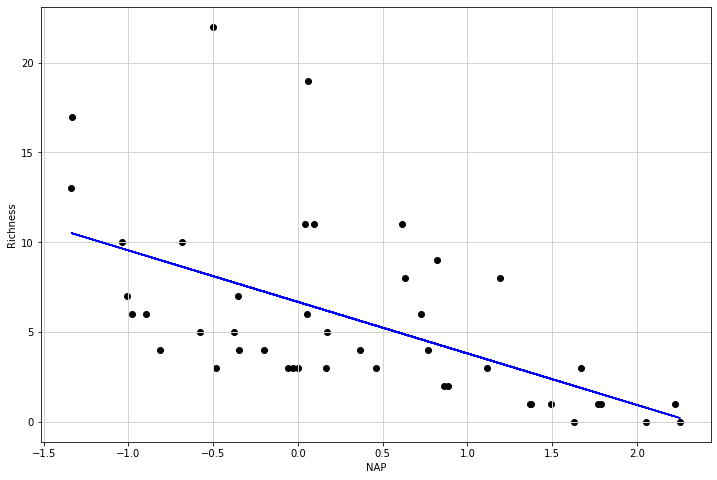

In [25]:
X = rikz[['NAP']]
y = rikz[['Richness']]

X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
predicted = model.fittedvalues
plt.figure(figsize=(12,8))
plt.scatter(X['NAP'], y, color='black')
plt.plot(X['NAP'], predicted, color='blue')
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.ylabel('Richness')
plt.xlabel('NAP')
plt.show()

In [29]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Richness   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     20.66
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           4.42e-05
Time:                        00:04:40   Log-Likelihood:                -126.98
No. Observations:                  45   AIC:                             258.0
Df Residuals:                      43   BIC:                             261.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6857      0.658     10.164      0.000       5.359       8.012
NAP           -2.8669      0.631     -4.545      0.000      -4.139      -1.595
==============================================================================
Omnibus:                       22.125   Durbin-Watson:                   1.259
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.991
Skew:                           1.590   Prob(JB):                     1.13e-07
Kurtosis:                       5.637   Cond. No.                         1.42
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""